# ML Internship Final Project

## 📌 Project Title: Loan Default Prediction System

#### Project Title
**Loan Default Prediction System**

#### Objective
This project builds a machine learning model to predict whether a loan applicant is likely to **default** or **repay** their loan, based on historical applicant data. The goal is to help identify risky applicants before a loan is approved.

#### Dataset
The dataset used is the **Loan Prediction Dataset**, which contains historical records of loan applicants and whether their loan was approved.

- **Source:** Loan Prediction Problem Dataset (Kaggle)
- **File:** `loan_data.csv`
- **Size:** 614 labeled records (training data)

#### Features

| Feature | Description |
|---|---|
| Loan_ID | Unique identifier for each loan application |
| Gender | Applicant's gender |
| Married | Marital status |
| Dependents | Number of dependents |
| Education | Graduate / Not Graduate |
| Self_Employed | Whether the applicant is self-employed |
| ApplicantIncome | Applicant's monthly income |
| CoapplicantIncome | Co-applicant's monthly income |
| LoanAmount | Loan amount requested (in thousands) |
| Loan_Amount_Term | Loan repayment term (in months) |
| Credit_History | Whether the applicant has a good credit history (1 = yes, 0 = no) |
| Property_Area | Urban / Semiurban / Rural |
| **Loan_Status** (Target) | Whether the loan was approved (Y) or not (N) |

### Step 1 – Data Preprocessing

In [13]:
# Import the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [18]:
# load the dataset
df = pd.read_csv("loan_data.csv")
print(df.head(10))

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   
5  LP001011   Male     Yes          2      Graduate           Yes   
6  LP001013   Male     Yes          0  Not Graduate            No   
7  LP001014   Male     Yes         3+      Graduate            No   
8  LP001018   Male     Yes          2      Graduate            No   
9  LP001020   Male     Yes          1      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000         

In [19]:
print(df.tail(10))

      Loan_ID  Gender Married Dependents     Education Self_Employed  \
604  LP002959  Female     Yes          1      Graduate            No   
605  LP002960    Male     Yes          0  Not Graduate            No   
606  LP002961    Male     Yes          1      Graduate            No   
607  LP002964    Male     Yes          2  Not Graduate            No   
608  LP002974    Male     Yes          0      Graduate            No   
609  LP002978  Female      No          0      Graduate            No   
610  LP002979    Male     Yes         3+      Graduate            No   
611  LP002983    Male     Yes          1      Graduate            No   
612  LP002984    Male     Yes          2      Graduate            No   
613  LP002990  Female      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
604            12000                0.0       496.0             360.0   
605             2400             3800.0         NaN          

In [20]:
# Explore the dataset using info() & describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [21]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [22]:
# Remove unnecessary columns
data = df.copy()  # copy the dataset to new variable
data.drop(columns=["Loan_ID"], inplace=True, axis=1)

In [23]:
# Looking to the missing values
data.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [27]:
# 1. Handle missing values by mode imputation
data["Gender"] = data["Gender"].fillna(data["Gender"].mode()[0])
data["Married"] = data["Married"].fillna(data["Married"].mode()[0])
data["Dependents"] = data["Dependents"].fillna(data["Dependents"].mode()[0])
data["Self_Employed"] = data["Self_Employed"].fillna(data["Self_Employed"].mode()[0])
data["Loan_Amount_Term"] = data["Loan_Amount_Term"].fillna(data["Loan_Amount_Term"].mode()[0])
data["Credit_History"] = data["Credit_History"].fillna(data["Credit_History"].mode()[0])

In [28]:
# 2. Handle missing values by mean imputation
data["LoanAmount"] = data["LoanAmount"].fillna(data["LoanAmount"].mean())

In [30]:
# Dropping the duplicates
data.duplicated().sum()   # no duplicates

np.int64(0)

In [31]:
print(data.head(10))

  Gender Married Dependents     Education Self_Employed  ApplicantIncome  \
0   Male      No          0      Graduate            No             5849   
1   Male     Yes          1      Graduate            No             4583   
2   Male     Yes          0      Graduate           Yes             3000   
3   Male     Yes          0  Not Graduate            No             2583   
4   Male      No          0      Graduate            No             6000   
5   Male     Yes          2      Graduate           Yes             5417   
6   Male     Yes          0  Not Graduate            No             2333   
7   Male     Yes         3+      Graduate            No             3036   
8   Male     Yes          2      Graduate            No             4006   
9   Male     Yes          1      Graduate            No            12841   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0  146.412162             360.0             1.0   
1             1508.0  1

In [33]:
# Check if missing values still exist
data.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [34]:
data["Loan_Amount_Term"].unique()

array([360., 120., 240., 180.,  60., 300., 480.,  36.,  84.,  12.])

In [35]:
# Encoding the categorical features
data["Gender"] = data["Gender"].map({"Male": 0, "Female": 1})
data["Married"] = data["Married"].map({"No": 0, "Yes": 1})
data["Education"] = data["Education"].map({"Not Graduate": 0, "Graduate": 1})
data["Self_Employed"] = data["Self_Employed"].map({"No": 0, "Yes": 1})
data["Credit_History"] = data["Credit_History"].map({0.0: 0, 1.0: 1})
data["Loan_Status"] = data["Loan_Status"].map({"N": 0, "Y": 1})

In [36]:
print(data.head(10))

   Gender  Married Dependents  Education  Self_Employed  ApplicantIncome  \
0       0        0          0          1              0             5849   
1       0        1          1          1              0             4583   
2       0        1          0          1              1             3000   
3       0        1          0          0              0             2583   
4       0        0          0          1              0             6000   
5       0        1          2          1              1             5417   
6       0        1          0          0              0             2333   
7       0        1         3+          1              0             3036   
8       0        1          2          1              0             4006   
9       0        1          1          1              0            12841   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0  146.412162             360.0               1   
1             1508.0  1

In [40]:
data_encoded = pd.get_dummies(data, columns=["Dependents","Property_Area"], drop_first=True)
print(data_encoded.head(10))

   Gender  Married  Education  Self_Employed  ApplicantIncome  \
0       0        0          1              0             5849   
1       0        1          1              0             4583   
2       0        1          1              1             3000   
3       0        1          0              0             2583   
4       0        0          1              0             6000   
5       0        1          1              1             5417   
6       0        1          0              0             2333   
7       0        1          1              0             3036   
8       0        1          1              0             4006   
9       0        1          1              0            12841   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0  146.412162             360.0               1   
1             1508.0  128.000000             360.0               1   
2                0.0   66.000000             360.0               1   
3   

### Step 2 – Exploratory Data Analysis (EDA)

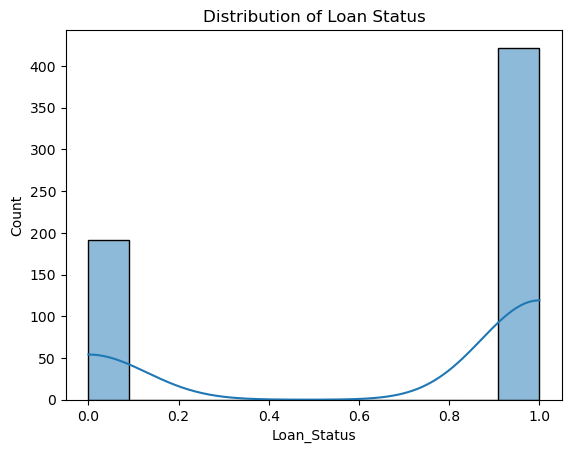

In [47]:
# Histogram of Loan Status
sns.histplot(data=data_encoded, x='Loan_Status', kde=True)
plt.title("Distribution of Loan Status")
plt.show()

**a. Distribution of Loan Status:**

The two bars are noticeably uneven: far more approved (`Y`) loans than rejected (`N`) ones, roughly a 2:1 split. This confirms `Loan_Status` is an imbalanced target, which matters for whatever model comes next — plain accuracy will be a misleading metric here, and `stratify=y` in the split will be the right call.


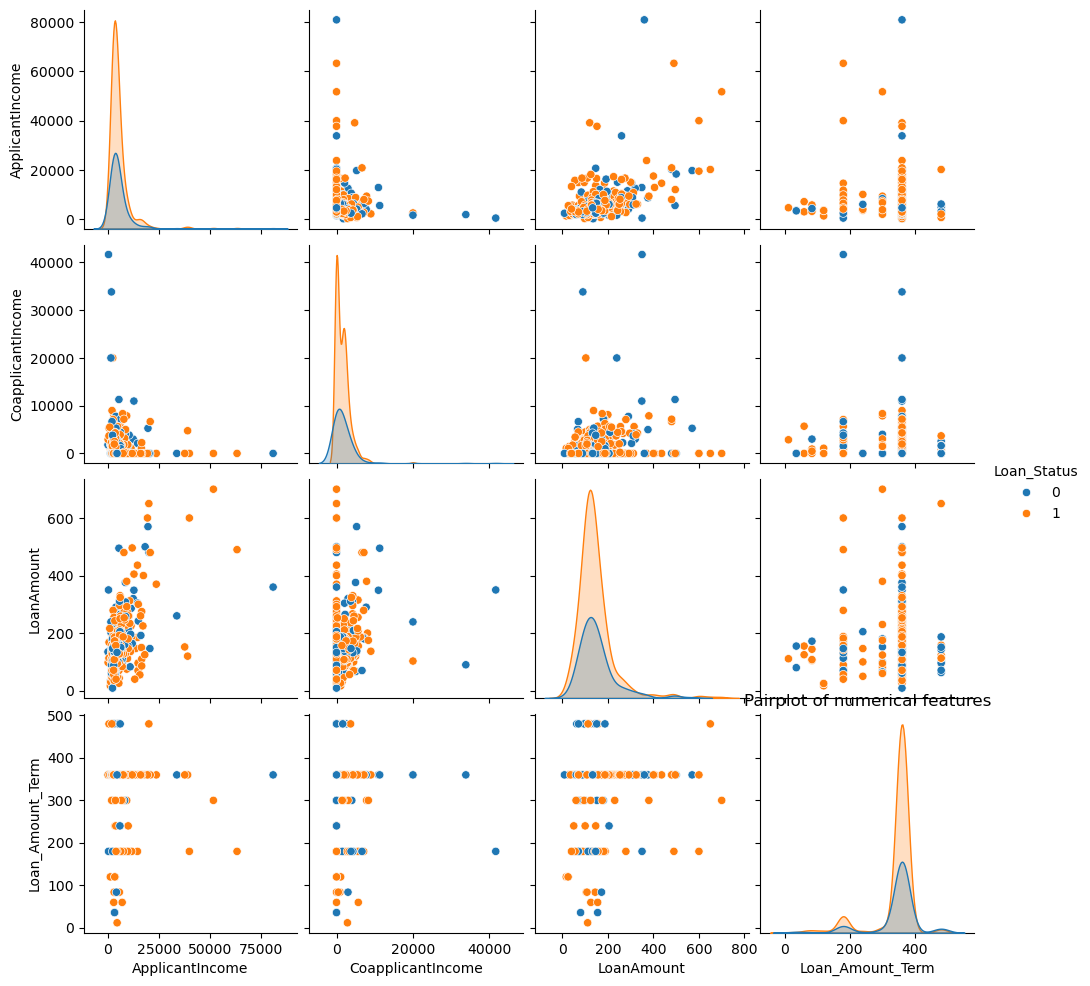

In [46]:
# Pairplot of numerical features
numerical_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]

sns.pairplot(data_encoded[numerical_cols + ["Loan_Status"]], hue='Loan_Status')
plt.title("Pairplot of numerical features")
plt.show()

**b. Pairplot of Numerical Features:**

Across `ApplicantIncome`, `CoapplicantIncome`, `LoanAmount`, and `Loan_Amount_Term`, the approved vs. rejected classes overlap heavily in every pairwise scatter — there's no single numerical feature (or pair of them) that visibly separates the two outcomes on its own. This is a useful negative finding: it suggests these continuous features alone won't carry a classifier very far, and categorical features (especially `Credit_History`) are likely doing more of the work.

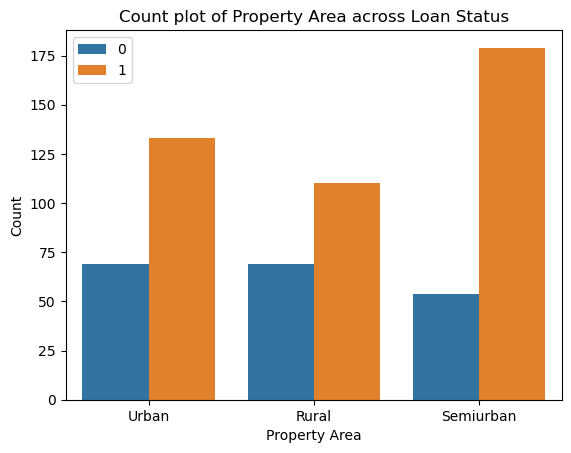

In [56]:
# Count plot of Property Area across Loan Status
sns.countplot(data=data, x='Property_Area', hue='Loan_Status')
plt.title("Count plot of Property Area across Loan Status")
plt.xlabel("Property Area")
plt.ylabel("Count")
plt.legend()
plt.show()

**c. Count Plot of Property Area across Loan Status:**

Semiurban properties show the highest approval count and also the best approval-to-rejection ratio among the three areas; Rural and Urban both show more rejections proportionally. This is a well-known pattern in this dataset and suggests `Property_Area` (specifically the Semiurban dummy) is a meaningful predictor.

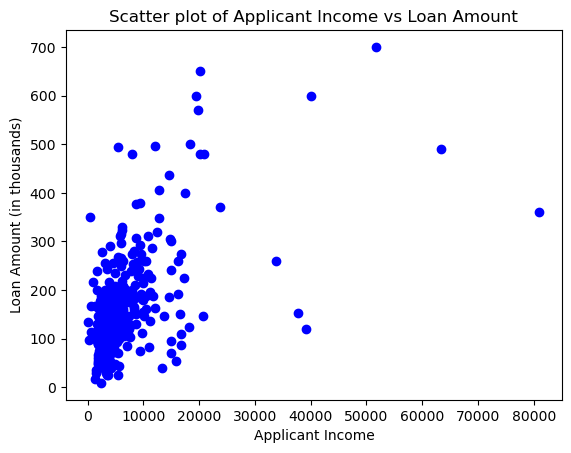

In [51]:
# Scatter plot of Applicant Income vs Loan Amount
plt.scatter(data_encoded["ApplicantIncome"], data_encoded["LoanAmount"], marker="o", color="blue")
plt.title("Scatter plot of Applicant Income vs Loan Amount")
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount (in thousands)")
plt.show()

**d. Scatter: Applicant Income vs Loan Amount:**

A loose, mildly positive relationship — higher incomes tend toward slightly higher loan amounts — but the cloud is wide and there are a few extreme outliers (very high income, moderate loan amount). Not a strong linear relationship, so this pair alone won't be a powerful predictor.

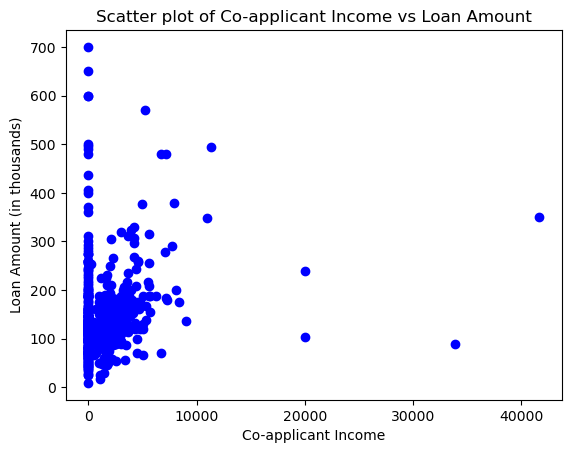

In [52]:
# Scatter plot of Co-applicant Income vs Loan Amount
plt.scatter(data_encoded["CoapplicantIncome"], data_encoded["LoanAmount"], marker="o", color="blue")
plt.title("Scatter plot of Co-applicant Income vs Loan Amount")
plt.xlabel("Co-applicant Income")
plt.ylabel("Loan Amount (in thousands)")
plt.show()

**e. Scatter: Co-applicant Income vs Loan Amount:**

Similar story, but noisier — a large cluster sits at `CoapplicantIncome = 0` (no co-applicant) spanning the full range of loan amounts, with the non-zero co-applicant points showing no clear trend. This tells you `CoapplicantIncome = 0` is doing double duty as both "no co-applicant" and "co-applicant with zero income" — worth being aware of if this feature goes into a model as-is.

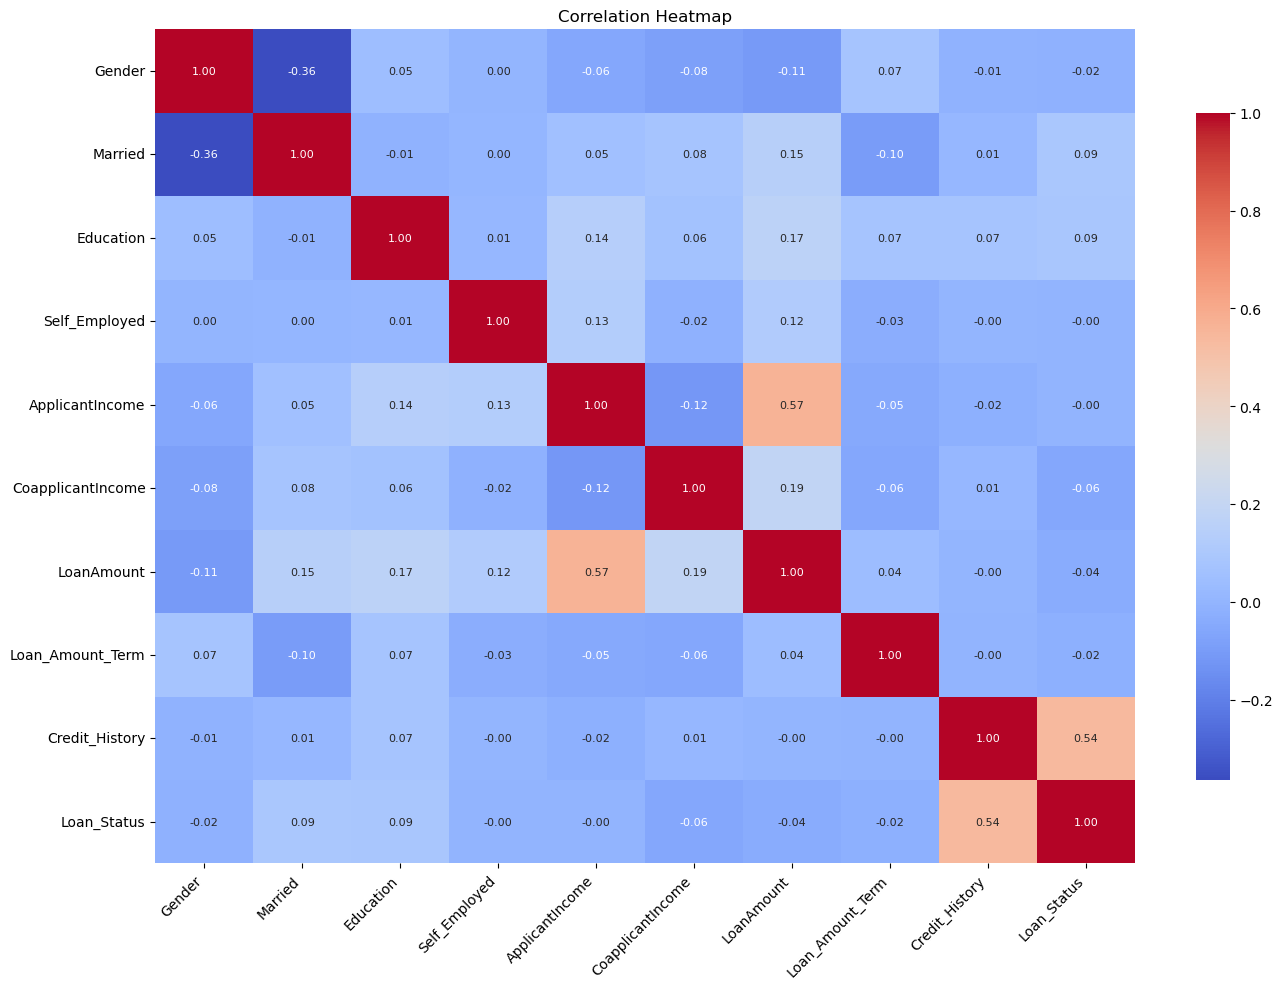

In [62]:
# Correlation Heatmap of all features
plt.figure(figsize=(14, 10))
corr = data.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**f. Correlation Heatmap:**

The strongest relationship by far is between `ApplicantIncome` and `LoanAmount` (moderate positive correlation, as the scatter above suggested), which is intuitive — larger loans tend to go with larger incomes. Most other pairs are weak. Notably, `Credit_History` doesn't show a strong linear correlation with `Loan_Status` in this view, which can be surprising — but that's a limitation of Pearson correlation on what's actually a categorical relationship, not evidence it's unimportant (the next plot shows why).

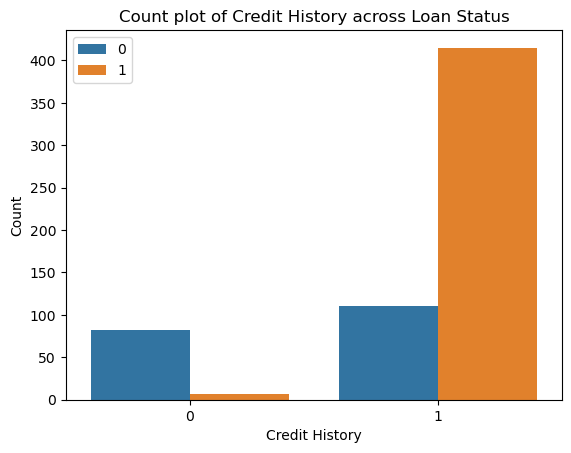

In [65]:
# Count plot of Credit History across Loan Status
sns.countplot(data=data, x='Credit_History', hue='Loan_Status')
plt.title("Count plot of Credit History across Loan Status")
plt.xlabel("Credit History")
plt.ylabel("Count")
plt.legend()
plt.show()

**g. Count Plot of Credit History across Loan Status:**

This is the most decisive plot in the notebook: applicants with `Credit_History = 1` are approved at a dramatically higher rate than those with `Credit_History = 0`, where rejections dominate. This is the single strongest signal in the dataset for predicting `Loan_Status`, even though the correlation heatmap undersold it — a good example of why it's worth pairing a correlation matrix with categorical count plots rather than relying on one or the other.

### Step 3 – Model Building

In [66]:
# Split
X = data_encoded.drop("Loan_Status", axis=1)
y = data_encoded["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40, stratify=y)  # stratify=y keeps the same proportion of approved/rejected loans in both train and test sets

In [67]:
# Scaling the numerical features
numerical_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [68]:
# 1. Gaussian Naive Bayes model

# train the model
nb_model = GaussianNB()
nb_model.fit(X_train,y_train)

# predict
y_pred_nb = nb_model.predict(X_test)

# evaluate
print("Evaluation of Gaussian Naive Bayes model")
print("Test Accuracy:", accuracy_score(y_test,y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred_nb))
print("Classification Report:\n", classification_report(y_test,y_pred_nb))

Evaluation of Gaussian Naive Bayes model
Test Accuracy: 0.7886178861788617
Confusion Matrix:
 [[15 23]
 [ 3 82]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.39      0.54        38
           1       0.78      0.96      0.86        85

    accuracy                           0.79       123
   macro avg       0.81      0.68      0.70       123
weighted avg       0.80      0.79      0.76       123



In [70]:
# 2. Logistic Regression model

# train the model
lr_model = LogisticRegression(solver="liblinear", random_state=40)
lr_model.fit(X_train,y_train)

# predict
y_pred_lr = lr_model.predict(X_test)

# evaluate
print("Evaluation of Logistic Regression model")
print("Test Accuracy:", accuracy_score(y_test,y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred_lr))
print("Classification Report:\n", classification_report(y_test,y_pred_lr))

Evaluation of Logistic Regression model
Test Accuracy: 0.7967479674796748
Confusion Matrix:
 [[14 24]
 [ 1 84]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.37      0.53        38
           1       0.78      0.99      0.87        85

    accuracy                           0.80       123
   macro avg       0.86      0.68      0.70       123
weighted avg       0.83      0.80      0.76       123



In [71]:
# 3. Decision Tree model

# train the model
dt_model = DecisionTreeClassifier(random_state=40)
dt_model.fit(X_train,y_train)

# predict
y_pred_dt = dt_model.predict(X_test)

# evaluate
print("Evaluation of Decision Tree model")
print("Test Accuracy:", accuracy_score(y_test,y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred_dt))
print("Classification Report:\n", classification_report(y_test,y_pred_dt))

Evaluation of Decision Tree model
Test Accuracy: 0.6666666666666666
Confusion Matrix:
 [[19 19]
 [22 63]]
Classification Report:
               precision    recall  f1-score   support

           0       0.46      0.50      0.48        38
           1       0.77      0.74      0.75        85

    accuracy                           0.67       123
   macro avg       0.62      0.62      0.62       123
weighted avg       0.67      0.67      0.67       123



In [73]:
# 4. Random Forest model

# train the model
rf_model = RandomForestClassifier(random_state=40)
rf_model.fit(X_train,y_train)

# predict
y_pred_rf = rf_model.predict(X_test)

# evaluate
print("Evaluation of Random Forest model")
print("Test Accuracy:", accuracy_score(y_test,y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred_rf))
print("Classification Report:\n", classification_report(y_test,y_pred_rf))

Evaluation of Random Forest model
Test Accuracy: 0.7560975609756098
Confusion Matrix:
 [[13 25]
 [ 5 80]]
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.34      0.46        38
           1       0.76      0.94      0.84        85

    accuracy                           0.76       123
   macro avg       0.74      0.64      0.65       123
weighted avg       0.75      0.76      0.73       123



### Step 4 – Model Comparison

| Model | Accuracy | Macro F1 | Weighted F1 | Reject (0) Precision/Recall | Approve (1) Precision/Recall |
|---|---|---|---|---|---|
| Naive Bayes | 78.9% | 0.70 | 0.76 | 0.83 / 0.39 | 0.78 / 0.96 |
| Logistic Regression | **79.7%** | 0.70 | 0.76 | 0.93 / 0.37 | 0.78 / 0.99 |
| Decision Tree | 66.7% | 0.62 | 0.67 | 0.46 / 0.50 | 0.77 / 0.74 |
| Random Forest | 75.6% | 0.65 | 0.73 | 0.72 / 0.34 | 0.76 / 0.94 |

Logistic Regression edges out Naive Bayes on raw accuracy, but the two are effectively tied once macro F1 is considered — a more honest metric here given the class imbalance in `Loan_Status`. Both comfortably outperform Decision Tree and Random Forest.

This is a somewhat unusual result: ensemble methods like Random Forest often beat simpler models, but with only 614 rows and a 2:1 class imbalance, the extra model complexity isn't paying off — Random Forest still under-recalls the minority class (34%), and a single unpruned Decision Tree overfits the training split, trading overall accuracy for a more balanced (but weaker across the board) result.

**Choosing a "best" model depends on what error costs more:**
- **If minimizing false approvals matters most** (i.e., you'd rather flag a borderline applicant for review than risk approving a real default), Decision Tree's 50% recall on the Reject class — while its weakest metric overall — is actually the best of the four at catching true rejections.
- **If overall correctness matters most** and the cost of a missed rejection is comparable to a missed approval, Logistic Regression is the strongest all-around choice, with the added benefit of being simple to interpret (coefficients directly show each feature's contribution to approval odds).
- **Naive Bayes is a close second choice** to Logistic Regression on every aggregate metric, and being probabilistic, it's worth keeping as a fast, interpretable baseline.

Given the tie on macro/weighted F1, **Logistic Regression is the recommended model** for this project, with the caveat that its low reject-recall (37%) means it will still miss roughly 6 in 10 applicants who should have been rejected — a limitation worth stating plainly rather than hiding behind the headline accuracy number.

### Step 5 - Explanation of Findings and Insights

**Credit History is the dominant signal, not income.** The EDA in Step 2 already hinted at this — the correlation heatmap understated `Credit_History`'s importance because the relationship is categorical, not linear, but the count plot showed applicants with `Credit_History = 1` are approved at a dramatically higher rate. That pattern carries straight through to the models: none of the four algorithms needed complex feature interactions to perform reasonably well, which is consistent with one or two features (Credit History, and to a lesser extent Property Area) carrying most of the predictive weight.

**Class imbalance limits every model equally.** All four models — spanning a probabilistic, a linear, a tree, and an ensemble approach — show the same weakness: strong recall on "Approve" (74–99%) and weak recall on "Reject" (34–50%). Since this pattern holds across fundamentally different algorithms, the imbalance in the training data is the more likely explanation than any single model's limitations. A future iteration would benefit from class-weighting (`class_weight="balanced"` in Logistic Regression/Random Forest) or resampling the minority class, rather than switching models again.

**Simpler models matched or beat more complex ones on this dataset.** Logistic Regression and Naive Bayes both outperformed Decision Tree and Random Forest. With only 614 rows, there isn't enough data for the added flexibility of tree ensembles to pay off — a useful, generalizable lesson: model complexity should match dataset size, and it's worth always benchmarking a simple baseline before reaching for something heavier.

**Two limitations to disclose alongside these results:**
- The test set is only 123 rows, so accuracy differences of 1–2 points between models (e.g., Logistic Regression's 79.7% vs. Naive Bayes' 78.9%) are within noise — the two should be treated as tied rather than one being definitively "better."
- `LoanAmount`'s missing values were imputed using the mean of the *full* dataset before the train/test split, meaning the test set had a small, indirect influence on a value used during training. This is a minor leak, unlikely to have shifted results dramatically given `LoanAmount`'s weak standalone relationship with `Loan_Status`, but it should be corrected (compute the mean from `X_train` only) before treating these numbers as final.